In [4]:
import os 
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/shogohuangg/thais/Thais.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2186.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2247.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2201.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2201.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/Thais.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2231.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2247.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2186.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2213.wav
/kaggle/input/datasets/shogohuangg/training-scaffold/2231.csv
/kaggle/input/datasets/shogohuangg/training-scaffold/2213.csv


2.10.0+cu128
True
Detected audio files: ['/kaggle/input/datasets/shogohuangg/training-scaffold/2186.wav', '/kaggle/input/datasets/shogohuangg/training-scaffold/2201.wav', '/kaggle/input/datasets/shogohuangg/training-scaffold/2213.wav', '/kaggle/input/datasets/shogohuangg/training-scaffold/2231.wav', '/kaggle/input/datasets/shogohuangg/training-scaffold/2247.wav']
Detected notation files: ['/kaggle/input/datasets/shogohuangg/training-scaffold/2186.csv', '/kaggle/input/datasets/shogohuangg/training-scaffold/2201.csv', '/kaggle/input/datasets/shogohuangg/training-scaffold/2213.csv', '/kaggle/input/datasets/shogohuangg/training-scaffold/2231.csv', '/kaggle/input/datasets/shogohuangg/training-scaffold/2247.csv']
Batch spectrogram shape: torch.Size([1, 1, 1025, 18466])
Batch piano roll shape: torch.Size([1, 18466, 88])
Batch spectrogram shape: torch.Size([1, 1, 1025, 11566])
Batch piano roll shape: torch.Size([1, 11566, 88])
Batch spectrogram shape: torch.Size([1, 1, 1025, 9991])
Batch piano

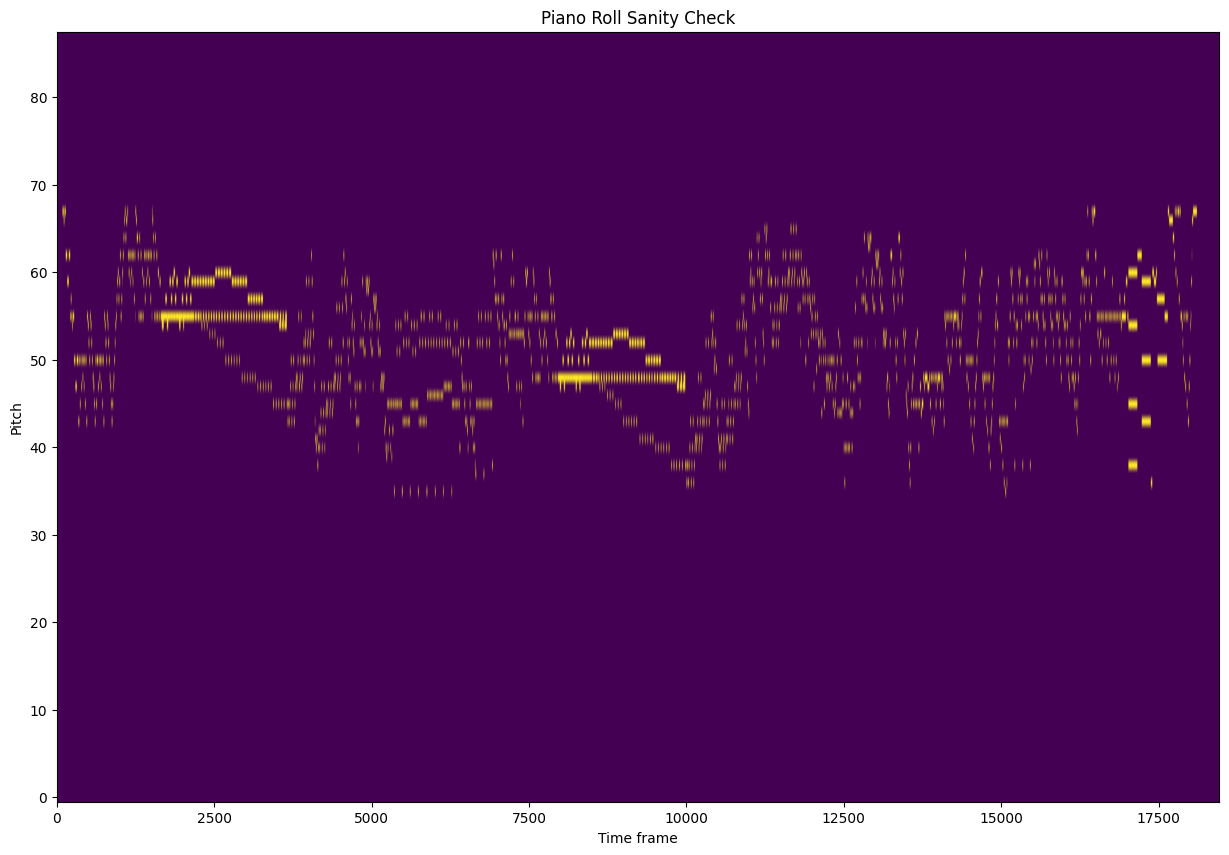

CRNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=(4, 1), stride=(4, 1), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=(4, 1), stride=(4, 1), padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(1024, 128, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=88, bias=True)
)
torch.Size([1, 300, 88])
62 chunks covering the whole piece (18466 frames)
24 test chunks (6998 frames)
pos_weight: 20.0
Epoch [10/500], Train Loss: 0.3226, Test Loss: 1.3898
Epoch [20/500], Train Loss: 0.3230, Test Loss: 1.4618
Epoch [30/500], Train Loss: 0.3222, Test Loss: 1.5161

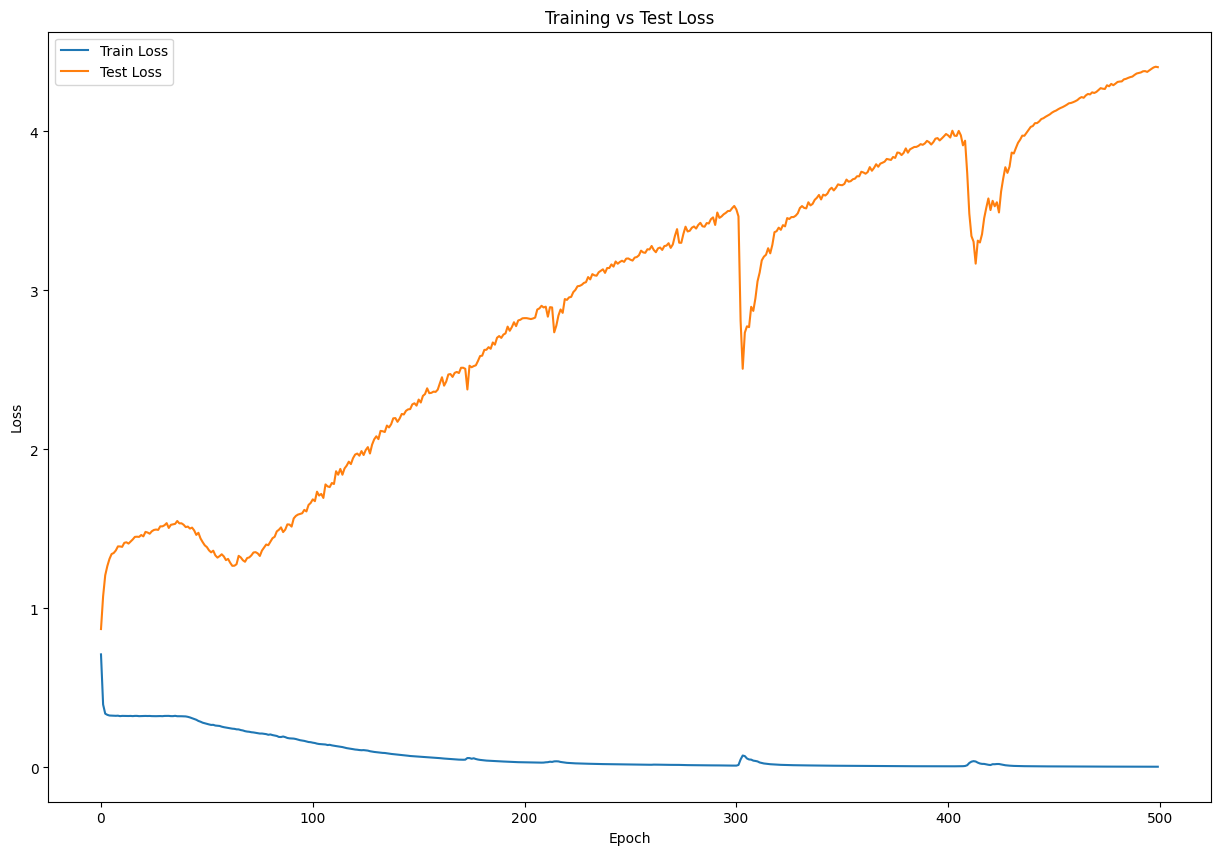

probs min/max/mean: 2.656028730285698e-10 0.9999949932098389 0.014154898934066296


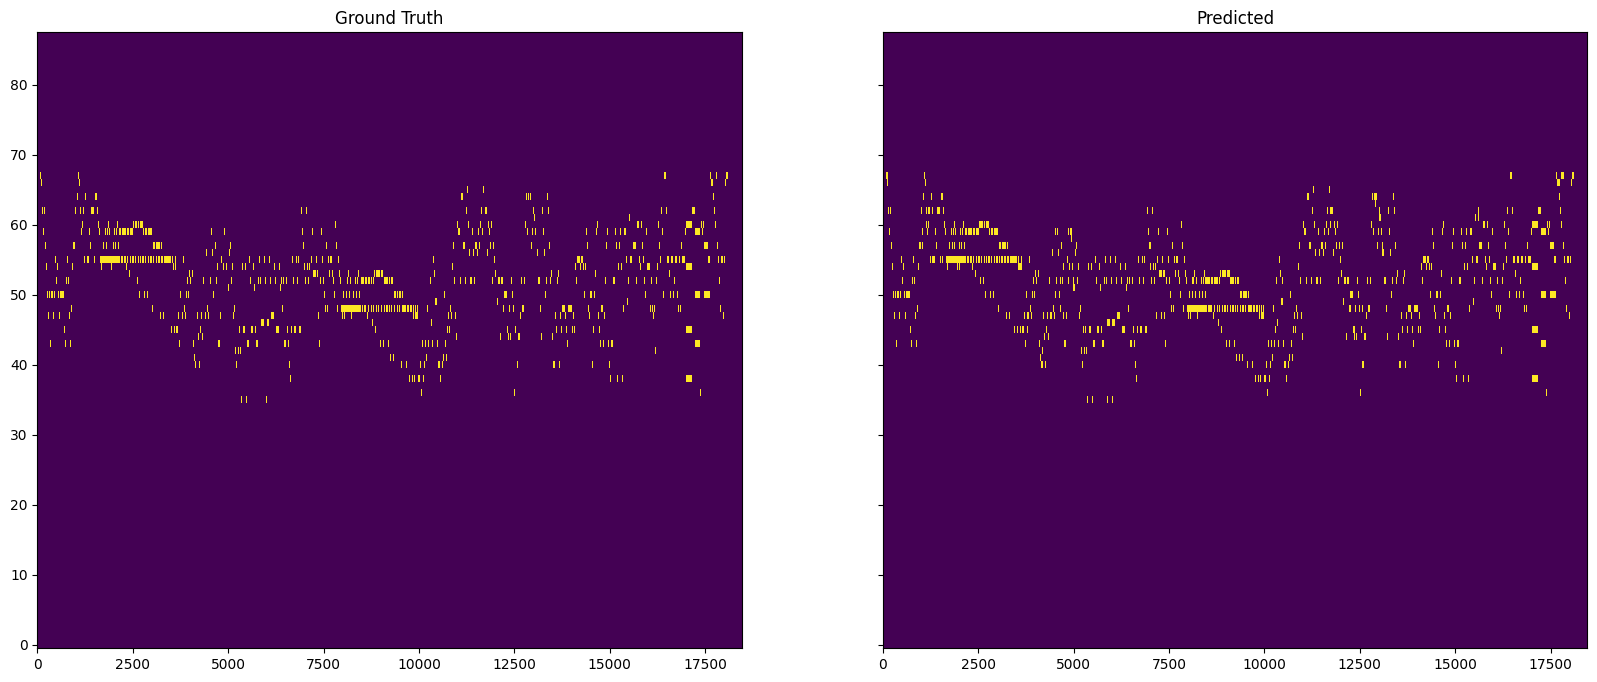

My recording spectrogram shape: torch.Size([1, 1025, 20968])
Predicted output shape: torch.Size([1, 20968, 88])


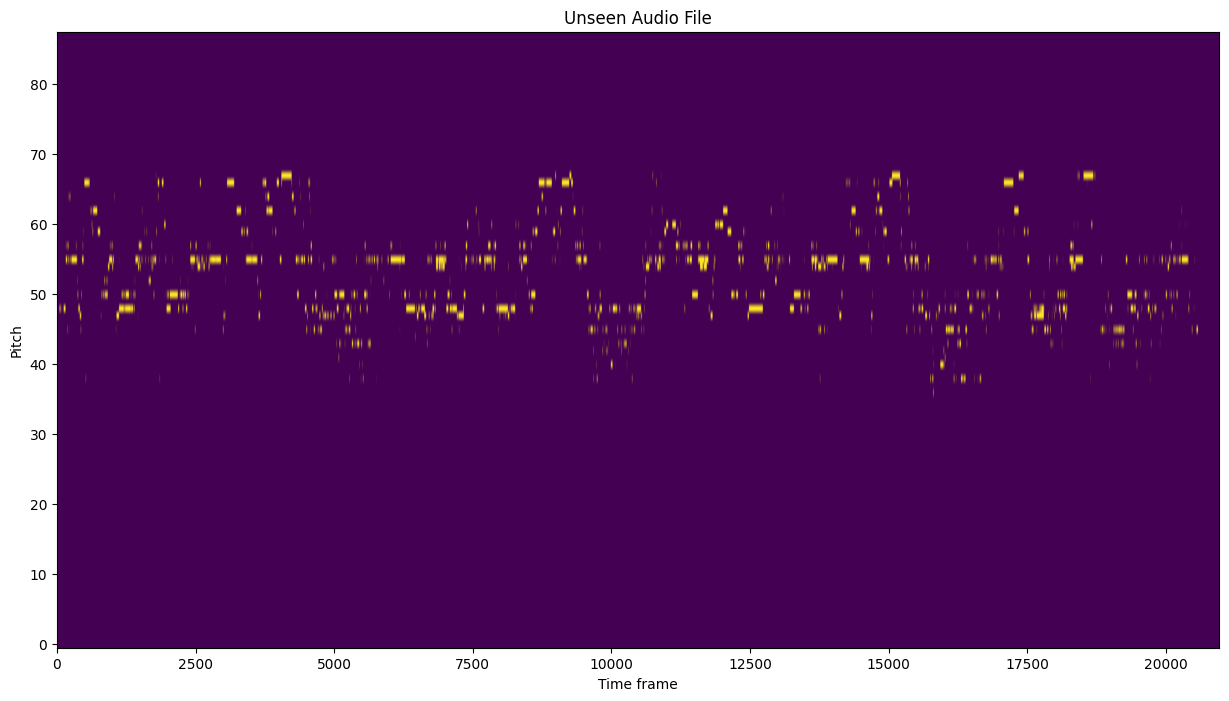

In [8]:
import torch
import librosa
import soundfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

print(torch.__version__)
print(torch.cuda.is_available())

data_dir = "/kaggle/input/datasets/shogohuangg/training-scaffold"

audio_files = [
    f"{data_dir}/2186.wav", f"{data_dir}/2201.wav", f"{data_dir}/2213.wav",
    f"{data_dir}/2231.wav", f"{data_dir}/2247.wav"
]
notation_files = [
    f"{data_dir}/2186.csv", f"{data_dir}/2201.csv", f"{data_dir}/2213.csv",
    f"{data_dir}/2231.csv", f"{data_dir}/2247.csv"
]

print("Detected audio files:", audio_files)
print("Detected notation files:", notation_files)


class MusicDataset(Dataset):
    def __init__(self, audio_files, label_files):
        self.audio_files = audio_files
        self.label_files = label_files

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, index):
        audio_path = self.audio_files[index]
        label_path = self.label_files[index]
        y, sr = librosa.load(audio_path, sr=None)
        D = librosa.stft(y)
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
        spectrogram_tensor = torch.tensor(S_db, dtype=torch.float32)
        spectrogram_tensor = spectrogram_tensor.unsqueeze(0)

        labels_df = pd.read_csv(label_path)
        hop_length = 512
        n_frame = spectrogram_tensor.shape[-1]
        piano_roll = torch.zeros(n_frame, 88)

        for _, row in labels_df.iterrows():
            start_frame = int(row['start_time']) // hop_length
            end_frame = int(row['end_time']) // hop_length
            pitch_idx = int(row['note']) - 21
            if 0 <= pitch_idx < 88:
                piano_roll[start_frame:end_frame, pitch_idx] = 1

       

        return spectrogram_tensor, piano_roll


train_dataset = MusicDataset(audio_files[:4], notation_files[:4])
test_dataset = MusicDataset(audio_files[4:], notation_files[4:])
dataset = train_dataset

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
for spectrogram, piano_roll in train_loader:
    print("Batch spectrogram shape:", spectrogram.shape)
    print("Batch piano roll shape:", piano_roll.shape)
    
spectrogram, piano_roll = dataset[0]
print("Spectrogram shape:", spectrogram.shape)
print("Piano roll shape:", piano_roll.shape)

plt.figure(figsize=(15,10))
plt.imshow(piano_roll.T, aspect='auto', origin='lower')
plt.xlabel("Time frame")
plt.ylabel("Pitch")
plt.title("Piano Roll Sanity Check")
plt.show()


class CRNN(nn.Module):
    def __init__(self, num_freq_bins=1025, cnn_channels=16, hidden_size=128, num_classes=88):
        super(CRNN, self).__init__()
        self.conv1 = nn.Conv2d(1, cnn_channels, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d((2,1))   

        self.conv2 = nn.Conv2d(cnn_channels, cnn_channels*2, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d((4,1))  

        self.conv3 = nn.Conv2d(cnn_channels*2, cnn_channels*2, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d((4,1))

        lstm_input = cnn_channels*2*32  

        self.lstm = nn.LSTM(input_size=lstm_input, hidden_size=hidden_size, num_layers=2,
                             batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        batch_size, channels, freq, time = x.shape
        x = x.permute(0,3,1,2).reshape(batch_size, time, channels*freq)
        x, _ = self.lstm(x)
        x = self.fc(x)
        return x

CHUNK_LEN = 300

def chunkify(spec, roll=None, chunk_len=CHUNK_LEN):
    """[1,F,T] -> X:[N,1,F,chunk_len], Y:[N,chunk_len,88], plus original T."""
    T = spec.shape[-1]
    pad = (-T) % chunk_len
    if pad:
        spec = torch.nn.functional.pad(spec, (0, pad))
        if roll is not None:
            roll = torch.nn.functional.pad(roll, (0, 0, 0, pad))
    n = spec.shape[-1] // chunk_len
    X = spec.reshape(1, spec.shape[1], n, chunk_len).permute(2, 0, 1, 3).contiguous()
    Y = roll.reshape(n, chunk_len, 88).contiguous() if roll is not None else None
    return X, Y, T

@torch.no_grad()
def predict_full(model, spec, batch=8):
    """Full-piece inference, chunked so long files don't OOM. -> probs [T,88]."""
    X, _, T = chunkify(spec)
    was_training = model.training
    model.eval()
    out = [torch.sigmoid(model(X[i:i+batch].cuda())).cpu() for i in range(0, len(X), batch)]
    if was_training:
        model.train()
    return torch.cat(out).reshape(-1, 88)[:T]
    
model = CRNN().cuda()
print(model)
output = model(spectrogram.unsqueeze(0)[:, :, :, :CHUNK_LEN].cuda())
print(output.shape)

epochs = 500
train_loss_history = []
test_loss_history = []

X, Y, n_frames = chunkify(spectrogram, piano_roll)
n_chunks = X.shape[0]
print(f"{n_chunks} chunks covering the whole piece ({n_frames} frames)")

test_spectrogram, test_piano_roll = test_dataset[0]
Xt, Yt, test_frames = chunkify(test_spectrogram, test_piano_roll)
n_test_chunks = Xt.shape[0]
print(f"{n_test_chunks} test chunks ({test_frames} frames)")
num_pos = piano_roll.sum()
num_neg = piano_roll.numel() - num_pos
pos_weight = (num_neg/num_pos).clone().detach().cuda()
pos_weight = torch.clamp(pos_weight, max=20.0)
print("pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100)

best_loss = float('inf')
best_state = None

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(n_chunks)
    running = 0.0
    for i in range(0, n_chunks, 8):
        idx = perm[i:i+8]
        xb, yb = X[idx].cuda(), Y[idx].cuda()
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running += loss.item() * xb.size(0)

    epoch_loss = running / n_chunks
    scheduler.step(epoch_loss)
    train_loss_history.append(epoch_loss)
    model.eval()
    test_running = 0.0
    with torch.no_grad():
        for i in range(0, n_test_chunks, 8):
            xb, yb = Xt[i:i+8].cuda(), Yt[i:i+8].cuda()
            test_running += criterion(model(xb), yb).item() * xb.size(0)
    test_loss_history.append(test_running / n_test_chunks)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {epoch_loss:.4f}, Test Loss: {test_loss_history[-1]:.4f}")

model.load_state_dict(best_state)

test_probs = predict_full(model, test_spectrogram)
test_loss = nn.BCELoss()(test_probs.clamp(1e-7, 1-1e-7), test_piano_roll[:test_probs.shape[0]])
print(f"Final test loss (held-out piece): {test_loss.item():.4f}")

plt.figure(figsize=(15,10))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.plot(train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.legend()
plt.show()

probs = predict_full(model, spectrogram)
preds = (probs > 0.5).float()
print("probs min/max/mean:", probs.min().item(), probs.max().item(), probs.mean().item())

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
axes[0].imshow(piano_roll[:n_frames].T, aspect='auto', origin='lower', interpolation='nearest')
axes[0].set_title("Ground Truth")
axes[1].imshow(preds.T, aspect='auto', origin='lower', interpolation='nearest')
axes[1].set_title("Predicted")
plt.show()

shogo_audio = "/kaggle/input/datasets/shogohuangg/training-scaffold/Thais.wav"

y, sr = librosa.load(shogo_audio, sr=None)
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)
my_spectrogram = torch.tensor(S_db, dtype=torch.float32)
my_spectrogram = my_spectrogram.unsqueeze(0)

print("My recording spectrogram shape:", my_spectrogram.shape)

model.eval()
with torch.no_grad():
    my_output = model(my_spectrogram.unsqueeze(0).cuda())
    my_probs = torch.sigmoid(my_output)
    my_preds = (my_probs > 0.5).float()

print("Predicted output shape:", my_preds.shape)

plt.figure(figsize=(15, 8))
plt.imshow(my_preds.squeeze(0).cpu().T, aspect='auto', origin='lower')
plt.xlabel("Time frame")
plt.ylabel("Pitch")
plt.title("Unseen Audio File")
plt.show()